# 05 — Feature Selection

**EduPredict — Student Exam Performance Prediction**

This notebook evaluates the 21 candidate input features using training data only.

Selection evidence:
1. Mutual Information for numerical features.
2. Permutation Importance from a Random Forest pipeline on a validation split.
3. A validation comparison between the full candidate feature set and the selected feature set.

**Important:** The final test set remains untouched during feature selection.

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
DATA_PATH = Path("../data/processed/student_performance_engineered.csv")

df_fe = pd.read_csv(DATA_PATH)

TARGET = "Exam_Score"

print("Dataset shape:", df_fe.shape)
print("Target:", TARGET)

X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET]

print("Candidate input features:", X.shape[1])

Dataset shape: (6606, 22)
Target: Exam_Score
Candidate input features: 21


## 1. Create the locked test set

The 80/20 test split is created before feature selection.

The test set will not be used for:
- feature selection,
- permutation-importance calculation,
- threshold decisions,
- or hyperparameter tuning.

It will be reserved for final model evaluation.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])
print("Training features:", X_train.shape[1])
print("Testing features :", X_test.shape[1])

Training rows: 5284
Testing rows : 1322
Training features: 21
Testing features : 21


In [4]:
X_train_fs, X_valid_fs, y_train_fs, y_valid_fs = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

print("Feature-selection training rows:", X_train_fs.shape[0])
print("Feature-selection validation rows:", X_valid_fs.shape[0])
print("Locked test rows:", X_test.shape[0])

Feature-selection training rows: 4227
Feature-selection validation rows: 1057
Locked test rows: 1322


## 2. Mutual Information — numerical features

Mutual Information can detect dependency that is not necessarily linear.

It is used here as a screening signal, not as the sole criterion for removing features.

In [5]:
numeric_features = X_train_fs.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train_fs.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nTotal candidate features:", X_train_fs.shape[1])

Numerical features: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Study_Attendance_Interaction', 'Study_Sleep_Interaction']

Categorical features: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Total candidate features: 21


In [6]:
mi_numeric = mutual_info_regression(
    X_train_fs[numeric_features],
    y_train_fs,
    random_state=42
)

mi_numeric_df = pd.DataFrame({
    "Feature": numeric_features,
    "Mutual_Information": mi_numeric
}).sort_values(
    "Mutual_Information",
    ascending=False
)

display(mi_numeric_df)

,Feature,Mutual_Information
6,Study_Attendance_Interaction,0.459824
1,Attendance,0.293958
0,Hours_Studied,0.150256
7,Study_Sleep_Interaction,0.097346
5,Physical_Activity,0.013931
4,Tutoring_Sessions,0.009522
3,Previous_Scores,0.009394
2,Sleep_Hours,0.000000


## 3. Preprocessing + Random Forest

Categorical variables are imputed and one-hot encoded inside a pipeline.

The preprocessing is fitted only on the feature-selection training data.

A Random Forest is used here because it can capture nonlinear relationships and interactions that simple correlation may miss.

In [7]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

print("Preprocessing and model pipeline created.")

Preprocessing and model pipeline created.


In [8]:
rf_pipeline.fit(X_train_fs, y_train_fs)

print("Random Forest feature-selection model trained successfully.")

Random Forest feature-selection model trained successfully.


## 4. Permutation Importance

Permutation importance measures how much validation performance changes when the information in one raw input feature is shuffled.

The scoring metric is negative RMSE because scikit-learn's permutation-importance API treats larger scores as better.

The original raw feature names are used, so categorical variables are evaluated as complete input features rather than individual one-hot columns.

In [9]:
perm = permutation_importance(
    rf_pipeline,
    X_valid_fs,
    y_valid_fs,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "Feature": X_valid_fs.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std
}).sort_values(
    "Importance_Mean",
    ascending=False
)

display(feature_importance_df)

,Feature,Importance_Mean,Importance_Std
19,Study_Attendance_Interaction,1.483640,0.063402
1,Attendance,0.765992,0.033567
6,Previous_Scores,0.132021,0.022815
2,Parental_Involvement,0.130238,0.016368
3,Access_to_Resources,0.117916,0.018053
20,Study_Sleep_Interaction,0.080463,0.013094
9,Tutoring_Sessions,0.063190,0.008306
16,Parental_Education_Level,0.031106,0.005325
10,Family_Income,0.027688,0.012270
13,Peer_Influence,0.013475,0.005086


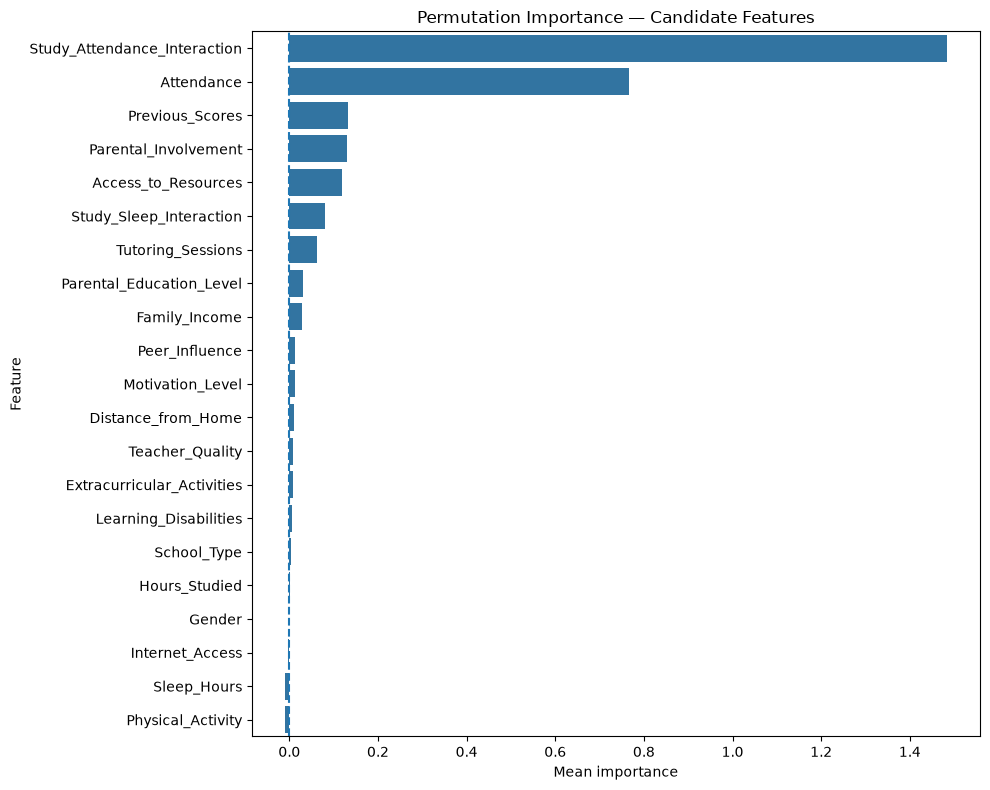

In [10]:
plt_importance = feature_importance_df.copy()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.barplot(
    data=plt_importance,
    x="Importance_Mean",
    y="Feature"
)

plt.axvline(0, linestyle="--")
plt.title("Permutation Importance — Candidate Features")
plt.xlabel("Mean importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 5. Candidate feature-selection rule

For this experiment, a feature is considered a **selection candidate** when its mean permutation importance is positive on the validation data.

This is a screening rule, not the final production decision.

Features with non-positive mean importance are flagged as potential removal candidates. The selected-feature model is then compared against the full-feature model using the same validation data.

We do not remove a feature simply because its Pearson correlation or Mutual Information is low.

In [11]:
selected_features = feature_importance_df.loc[
    feature_importance_df["Importance_Mean"] > 0,
    "Feature"
].tolist()

removed_candidates = feature_importance_df.loc[
    feature_importance_df["Importance_Mean"] <= 0,
    "Feature"
].tolist()

print("Selected candidate features:", len(selected_features))
print("Potential removal candidates:", len(removed_candidates))

print("\nSelected candidates:")
for feature in selected_features:
    print("-", feature)

print("\nPotential removal candidates:")
for feature in removed_candidates:
    print("-", feature)

Selected candidate features: 17
Potential removal candidates: 4

Selected candidates:
- Study_Attendance_Interaction
- Attendance
- Previous_Scores
- Parental_Involvement
- Access_to_Resources
- Study_Sleep_Interaction
- Tutoring_Sessions
- Parental_Education_Level
- Family_Income
- Peer_Influence
- Motivation_Level
- Distance_from_Home
- Teacher_Quality
- Extracurricular_Activities
- Learning_Disabilities
- School_Type
- Hours_Studied

Potential removal candidates:
- Gender
- Internet_Access
- Sleep_Hours
- Physical_Activity


## 6. Validation comparison — all features vs selected features

The following experiment checks whether removing non-positive permutation-importance features actually improves or harms validation performance.

This comparison uses the same validation set and the same Random Forest configuration.

The locked test set remains untouched.

In [12]:
def build_rf_pipeline(feature_columns):
    numeric = X_train_fs[feature_columns].select_dtypes(
        include=["int64", "float64"]
    ).columns.tolist()

    categorical = X_train_fs[feature_columns].select_dtypes(
        include=["object", "str"]
    ).columns.tolist()

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    prep = ColumnTransformer([
        ("num", num_pipe, numeric),
        ("cat", cat_pipe, categorical)
    ])

    return Pipeline([
        ("preprocessor", prep),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ])

In [13]:
all_features = X_train_fs.columns.tolist()

comparison_results = []

for label, feature_set in [
    ("All 21 candidate features", all_features),
    ("Permutation-selected features", selected_features)
]:
    pipe = build_rf_pipeline(feature_set)

    pipe.fit(
        X_train_fs[feature_set],
        y_train_fs
    )

    pred = pipe.predict(
        X_valid_fs[feature_set]
    )

    rmse = np.sqrt(
        mean_squared_error(y_valid_fs, pred)
    )

    comparison_results.append({
        "Feature_Set": label,
        "Feature_Count": len(feature_set),
        "MAE": mean_absolute_error(y_valid_fs, pred),
        "RMSE": rmse,
        "R2": r2_score(y_valid_fs, pred)
    })

comparison_df = pd.DataFrame(comparison_results)

display(comparison_df)

,Feature_Set,Feature_Count,MAE,RMSE,R2
0,All 21 candidate features,21,1.130430,2.297030,0.630358
1,Permutation-selected features,17,1.117181,2.281659,0.635289


## 7. Selection decision

Use the validation comparison above to make the final decision.

- If the selected-feature model performs similarly or better while using fewer features, feature reduction is justified.
- If the selected-feature model performs materially worse, retain the full candidate set and document that the permutation screen was not sufficient to improve predictive performance.
- Do not select a feature set merely because it is smaller.

The final decision must be based on the **actual validation metrics produced above**.

In [14]:
best_row = comparison_df.sort_values(
    "RMSE",
    ascending=True
).iloc[0]

print("Validation model with lowest RMSE:")
print(best_row.to_dict())

if best_row["Feature_Set"] == "Permutation-selected features":
    final_candidate_features = selected_features
    decision = "Use permutation-selected features as the candidate reduced feature set."
else:
    final_candidate_features = all_features
    decision = "Retain all candidate features because feature reduction did not improve validation RMSE."

print("\nDecision:")
print(decision)

print("\nFinal candidate feature count:", len(final_candidate_features))

Validation model with lowest RMSE:
{'Feature_Set': 'Permutation-selected features', 'Feature_Count': 17, 'MAE': 1.117180700094607, 'RMSE': 2.2816588120753085, 'R2': 0.6352885473516043}

Decision:
Use permutation-selected features as the candidate reduced feature set.

Final candidate feature count: 17


In [15]:
OUTPUT_DIR = Path("../outputs/metrics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

feature_importance_df.to_csv(
    OUTPUT_DIR / "permutation_feature_importance.csv",
    index=False
)

comparison_df.to_csv(
    OUTPUT_DIR / "feature_selection_comparison.csv",
    index=False
)

with open(
    OUTPUT_DIR / "selected_features.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        {
            "decision": decision,
            "features": final_candidate_features,
            "feature_count": len(final_candidate_features)
        },
        f,
        indent=2
    )

print("Feature-selection artifacts saved to:", OUTPUT_DIR)

Feature-selection artifacts saved to: ../outputs/metrics


# Feature Selection Summary

### Evidence used

1. Mutual Information for numerical features.
2. Random Forest permutation importance on a validation split.
3. Validation comparison of all candidate features versus the reduced candidate set.

### Leakage controls

- `Exam_Score` is never used as an input feature.
- The test set is locked during feature selection.
- Imputation and encoding are fitted inside the training pipeline.
- Feature selection uses training/validation data only.

### Next phase

The next notebook is **`06_pca_experiment.ipynb`**.

PCA will be treated as an experiment:
- compare no-PCA against PCA,
- inspect explained variance,
- test component counts,
- evaluate predictive performance,
- and decide whether dimensionality reduction is justified.

PCA will not be forced into the final production pipeline if it does not provide sufficient benefit or harms interpretability.
